# Exercise 1

Use the following code to generate a classification dataset:

Split the data into a train and test split, the test split being 25% of the initial dataset.
Apply a soft voting ensemble formed of a logistic regression algorithm, a random forest algorithm with 200 estimators, and Gaussian RBF kernel
SVM algorithm with γ = 1.5, on the train set.
Compute the accuracy on the test set and the output probability distribution of the 9th sample in the test set.


In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
X, Y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42,
)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

In [4]:
log_clf = LogisticRegression(solver="lbfgs", random_state=42)
rnd_clf = RandomForestClassifier(n_estimators=200, random_state=42)
svm_clf = SVC(gamma=1.5, probability=True, random_state=42)

voting_clf = VotingClassifier(
    estimators=[("lr", log_clf), ("rf", rnd_clf), ("svc", svm_clf)], voting="soft"
)
voting_clf.fit(X_train, Y_train)

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=42)),
                             ('svc',
                              SVC(gamma=1.5, probability=True,
                                  random_state=42))],
                 voting='soft')

In [5]:
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, Y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(Y_test, y_pred))

LogisticRegression 0.772
RandomForestClassifier 0.888
SVC 0.908
VotingClassifier 0.896


In [6]:
print(voting_clf.predict_proba([X_test[8]]))

[[0.04477741 0.04037507 0.91484753]]


# Exercise 2

Apply the PCA algorithm with 2 components, on the train set.

Compute the components, the explained variance ratio, and the inverse transformation of the 11th sample in the test set.


In [7]:
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles

X, Y = make_circles(n_samples=1000, factor=0.1, noise=0.01, random_state=42)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

In [8]:
pca = PCA(n_components=2)
X2D_train = pca.fit_transform(X_train)

In [9]:
pca.components_

array([[ 0.89907744, -0.43778964],
       [ 0.43778964,  0.89907744]])

In [10]:
pca.explained_variance_ratio_

array([0.51328691, 0.48671309])

In [11]:
X3D_inv_11 = pca.inverse_transform(X2D_train[10])
X3D_inv_11

array([ 0.98393382, -0.19518467])

# Exercise 3

Apply the full K-means clustering algorithm with K=5 and a maximum of 10 iterations, on the train set.

Compute the label of the 5th sample in the test set, the third cluster center, the inertia on the train set, the negative inertia on the test set, and the sihouette score.


In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

X, Y = make_circles(n_samples=1000, factor=0.5, noise=0.1, random_state=42)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

In [13]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], "k.", markersize=2)


def plot_centroids(centroids, weights=None, circle_color="w", cross_color="k"):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="o",
        s=35,
        linewidths=8,
        color=circle_color,
        zorder=10,
        alpha=0.9,
    )
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=35,
        linewidths=12,
        color=cross_color,
        zorder=11,
        alpha=1,
    )


def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution),
    )
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(
        Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors="k"
    )
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

In [14]:
kmeans = KMeans(
    n_clusters=5,
    init="random",
    n_init=1,
    algorithm="lloyd",
    max_iter=10,
    random_state=1,
)

kmeans.fit(X_train)

KMeans(init='random', max_iter=10, n_clusters=5, n_init=1, random_state=1)

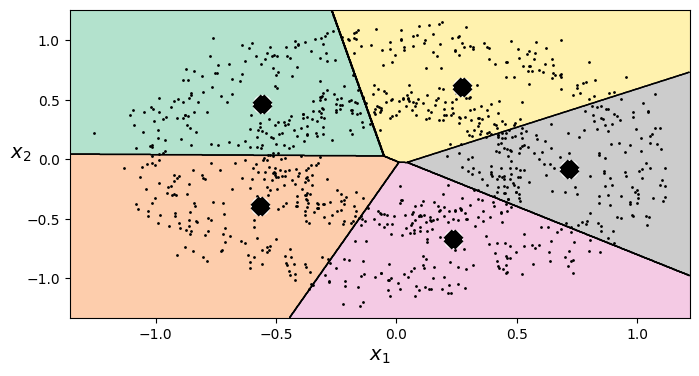

In [15]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

In [16]:
kmeans.labels_[4]

1

In [17]:
kmeans.cluster_centers_[2]

array([ 0.2353458 , -0.67241934])

In [18]:
kmeans.inertia_

104.20023362942058

In [19]:
kmeans.score(X_test)

-35.54523856722667

In [20]:
from sklearn.metrics import silhouette_score

silhouette_score(X_train, kmeans.labels_)

0.34728667936071483

# Exercise 4

Use the following code to generate a classification dataset:

Split the data into a train and test split, the test split being 25% of the initial dataset.
Apply a gradient boosting ensemble formed of 200 decision trees with maximum depth of 3, learning rate of 1.2, on the train set.

Compute the feature importances, the accuracy on the test set and the output probability distribution of the 11th sample in the test set.


In [21]:
from sklearn.ensemble import GradientBoostingClassifier

X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [22]:
gbrt = GradientBoostingClassifier(
    max_depth=3, n_estimators=200, learning_rate=1.2, random_state=42
)
gbrt.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=1.2, n_estimators=200, random_state=42)

In [23]:
feature_importances = gbrt.feature_importances_
feature_importances

array([0.10206914, 0.16930456, 0.39188816, 0.33673814])

In [24]:
accuracy = gbrt.score(X_test, y_test)
accuracy

0.864

In [25]:
probabilities = gbrt.predict_proba([X_test[10]])
probabilities

array([[0.02571222, 0.054552  , 0.91973579]])

# Exercise 5

Split the data into a train and test split, the test split being 5% of the
initial dataset.

Apply a gradient boosting ensemble formed of 200 decision trees with
maximum depth of 3, with a learning rate of 1.2, on the train set.
Compute the feature importances, the accuracy on the test set and the
output probability distribution of the 11th sample in the test set.


In [26]:
from sklearn.ensemble import GradientBoostingClassifier

X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.05
)

In [27]:
gbrt = GradientBoostingClassifier(
    max_depth=3, n_estimators=200, learning_rate=1.2, random_state=42
)
gbrt.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=1.2, n_estimators=200, random_state=42)

In [28]:
gbrt.feature_importances_

array([0.11601147, 0.15569403, 0.36239072, 0.36590378])

In [29]:
gbrt.score(X_test, y_test)

0.9

In [30]:
gbrt.predict_proba([X_test[10]])

array([[4.68144906e-14, 8.50648783e-12, 1.00000000e+00]])

# Exercise 6

Split the data into a train and test split, the test split being 20% of the
initial dataset.

Apply a ridge regression algorithm with lambda = 0.2
Compute W, W0 and the mean squared error on the test set


In [31]:
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

X, y = make_regression(n_samples=1000, n_features=1, noise=1, bias=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.20
)

In [32]:
ridge_reg = Ridge(alpha=0.2)
ridge_reg.fit(X_train, y_train)
ridge_reg.intercept_, ridge_reg.coef_

(1.990819970853543, array([16.74062352]))

# Exercise_7

Split the data into a train and test split, the test split being 25% of the
initial dataset.

Apply a polynomial kernel SVM algorithm with degree 2, coefficient 0.5, C=2, Epsilon=1, for 5000 epochs

Compute the second support vector and the mean squared error on the test set


In [33]:
from sklearn.svm import SVR

X, y = make_regression(n_samples=1000, n_features=2, noise=1, bias=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25
)

In [34]:
svm_poly_reg = SVR(kernel="poly", degree=2, coef0=0.5, C=2, epsilon=1)
svm_poly_reg.fit(X_train, y_train)

SVR(C=2, coef0=0.5, degree=2, epsilon=1, kernel='poly')

In [35]:
svm_poly_reg.support_vectors_[1]

array([0.11422765, 0.15030176])

In [36]:
y_predict = svm_poly_reg.predict(X_test)
mean_squared_error(y_test, y_predict)

0.9818168401064495

# Exercise 8

Split the data into a train and test split, the test split being 25% of the
initial dataset.

Apply the decision tree algorithm with a minimum of 5 samples in each leaf on the train set

Compute the feature importances, the accuracy on the test set and the output probability distribution for the 9th sample in the test set


In [37]:
from sklearn.tree import DecisionTreeClassifier

X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25
)

In [38]:
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [39]:
tree_clf.feature_importances_

array([0.70421374, 0.01645319, 0.16544231, 0.11389076])

In [40]:
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.608

In [41]:
tree_clf.predict_proba(X_test)

array([[0.        , 1.        ],
       [0.        , 1.        ],
       [0.99621212, 0.00378788],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.99621212, 0.00378788],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.94117647, 0.05882353],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.74      , 0.26      ],
       [0.        , 1.        ],
       [0.74      , 0.26      ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.88888889, 0.11111111],
       [0.99621212, 0.00378788],
       [0.        , 1.        ],
       [0.99621212, 0.00378788],
       [0.88888889, 0.11111111],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.99621212, 0.00378788],
       [0.99621212, 0.00378788],
       [0.        , 1.        ],
       [0.

# Exercise 9

Split the data into a train and test split, the test split being 25% of the
initial dataset.

Apply the locally linear embedding algorithm with 3 components and 6 neighbors on the train set

Compute the transformation of the 11th sample in the test set


In [42]:
from sklearn.datasets import make_s_curve
from sklearn.manifold import LocallyLinearEmbedding

X, y = make_s_curve(n_samples=1000, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25
)

In [43]:
lle = LocallyLinearEmbedding(n_components=3, n_neighbors=6, random_state=42)
X_train_reduced = lle.fit_transform(X_train)
X_test_reduced = lle.transform(X_test)

print(X_test[10])
print(X_test_reduced[10])

[-0.05242252  1.52874532 -1.99862499]
[ 0.04161253 -0.04042708  0.01086122]


# Exercise 10

Split the data into a train and test split, the test split being 15% of the
initial dataset.

Apply the stochastic gradient descent regression algorithm with L2 regularization with lambda = 0.01, for 150 epochs with a constant learning rate of LR = 0.005 on the train set

Compute W, W0 and the mean squared error on the test set


In [44]:
from sklearn.linear_model import SGDRegressor

X, y = make_regression(n_samples=1000, n_features=1, noise=0.5, bias=3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)

In [45]:
sgd_reg = SGDRegressor(
    max_iter=150,
    tol=1e-3,
    penalty="l2",
    alpha=0.01,
    eta0=0.005,
    learning_rate="constant",
    random_state=42,
)

sgd_reg.fit(X_train, y_train)

SGDRegressor(alpha=0.01, eta0=0.005, learning_rate='constant', max_iter=150,
             random_state=42)

In [46]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.00170797]), array([16.59436831]))

In [47]:
from sklearn.metrics import mean_squared_error

y_pred = sgd_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

0.260235092561629

# Exercise 11

Apply the lasso regression with lambda = 0.01
Compute W, W0, MSE


In [48]:
from sklearn.linear_model import Lasso

X, y = make_regression(n_samples=1000, n_features=1, noise=0.1, bias=1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [49]:
lasso_reg = Lasso(alpha=0.01)

lasso_reg.fit(X_train, y_train)

Lasso(alpha=0.01)

In [50]:
lasso_reg.coef_, lasso_reg.intercept_

(array([16.73361648]), 1.0018952808347954)

In [51]:
y_pred = lasso_reg.predict(X_test)
mse = mean_squared_error(y_pred, y_test)
mse

0.009077651854872984

# Exercise 12

Apply the linear soft margin SVM, C=100, Epochs=100000
Compute W, b, second support vector, accuracy on the test set, output probability disribution for the 8th sample


In [52]:
from sklearn.svm import LinearSVC

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [53]:
svm_clf = LinearSVC(C=100, max_iter=100000, loss="hinge", random_state=42)

svm_clf.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=100, loss='hinge', max_iter=100000, random_state=42)

In [54]:
w = svm_clf.coef_[0]
b = svm_clf.intercept_[0]

# Find support vectors (LinearSVC does not do this automatically)
t = y_train * 2 - 1
support_vectors_idx1 = (t * (X_train.dot(w) + b) <= 1).ravel()
svm_clf.support_vectors_ = X_train[support_vectors_idx1]

w, b, svm_clf.support_vectors_[1]

(array([-0.84675847,  2.27688532]),
 1.652206357323947,
 array([3.66699077, 0.52822446]))

In [55]:
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC doesn't have predict_proba by default, so we need to calibrate it
calibrated_svm = CalibratedClassifierCV(svm_clf, method="sigmoid", cv=3)
calibrated_svm.fit(X_train, y_train)

# Compute accuracy on test set
accuracy = calibrated_svm.score(X_test, y_test)
print("Accuracy on test set:", accuracy)

# Output probability distribution for the 8th sample (index 7)
prob_distribution = calibrated_svm.predict_proba([X_test[7]])
print("Probability distribution for 8th sample:", prob_distribution)

Accuracy on test set: 0.936
Probability distribution for 8th sample: [[0.02514435 0.97485565]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


# Exercise 13

Split the data into a train and test split, the test split being 25% of the initial dataset.
Apply the polynomial kernel SVM algorithm with degree 2, coefficient 0.5, C = 2 and gamma=1 for MNIST dataset on the train set.
Compute the second support vector and the mean squared error on the test set.

```
(array([0.11426769, 3.11010176]), 0.9511148401064861)
```


In [58]:
X, y = make_regression(
    n_samples=1000,
    n_features=5,
    noise=1,
    bias=2,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [60]:
svm_poly_reg = SVR(kernel="poly", degree=2, C=2, coef0=0.5, gamma=1)
svm_poly_reg.fit(X_train, y_train)

SVR(C=2, coef0=0.5, degree=2, gamma=1, kernel='poly')

In [63]:
y_pred = svm_poly_reg.predict(X_test)
mse = mean_squared_error(y_pred, y_test)

svm_poly_reg.support_vectors_[1], mse

(array([ 0.19259692,  0.0693698 ,  1.63579781,  2.39210964, -0.22104246]),
 1.2197974385376138)

# Exercise 14

Split the data into a train and test split, the test split being 25% of the initial dataset.
Apply the mini batch K-means clustering algorithm with K=3
Compute the label of the 8th sample in the test set, the first cluster center, the inertia on the train set, the negative inertia on the test set, and the adjusted Rand score.


In [71]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import MiniBatchKMeans


X, y = make_circles(n_samples=1000, factor=0.5, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [73]:
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X_train)

MiniBatchKMeans(n_clusters=5, random_state=42)

In [77]:
y_pred = minibatch_kmeans.predict(X_test)
minibatch_kmeans.labels_[8], minibatch_kmeans.cluster_centers_[
    0
], minibatch_kmeans.inertia_, minibatch_kmeans.score(X_test), adjusted_rand_score(
    y_test, y_pred
)

(1,
 array([0.30857443, 0.49862513]),
 109.45873274594227,
 -37.976238290765394,
 0.0024553226775934707)

# Exercise 15

Split the data into a train and test split, the test split being 20% of the initial dataset.

Apply the stochastic gradient descent regression algorithm with no regularization, for 100 epochs with a constant learning rate, on the train set

Compute W, W0, MSE


In [78]:
X, y = make_regression(n_samples=1000, n_features=1, noise=1, bias=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [79]:
sgd_reg = SGDRegressor(
    max_iter=100,
    tol=1e-3,
    penalty=None,
    learning_rate="constant",
    random_state=42,
)
sgd_reg.fit(X_train, y_train)

SGDRegressor(learning_rate='constant', max_iter=100, penalty=None,
             random_state=42)

In [80]:
sgd_reg.coef_, sgd_reg.intercept_, mean_squared_error(y_test, sgd_reg.predict(X_test))

(array([16.73754747]), array([2.00633662]), 0.938893509862377)